In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

REFORM_COLOR = '#12239E'
ACCENT_COLOR = '#E8102A'

In [31]:
df = pd.read_csv('../../data/processed/model_data.csv')

# same transforms as EDA
df['log_population_density'] = np.log1p(df['population_density'])
df['log_foreign_born_pct'] = np.log1p(df['foreign_born_pct'])

FEATURES = ['leave_vote_share', 'degree_pct', 'median_age', 'median_weekly_wage',
            'claimant_rate', 'log_foreign_born_pct', 'log_population_density',
            'ethnic_minority_pct', 'deprivation_score', 'is_scotland']

X = df[FEATURES]
y = df['reform_vote_share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 485  |  Test: 122


In [32]:
# VIF check for multicorrelation
vif = pd.DataFrame({
    'feature': FEATURES,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False).round(2)

print(vif.to_string(index=False))

               feature    VIF
    median_weekly_wage 174.91
            median_age 160.37
            degree_pct 144.11
      leave_vote_share 123.63
  log_foreign_born_pct  97.03
log_population_density  72.42
         claimant_rate  51.82
     deprivation_score  36.50
   ethnic_minority_pct  15.60
           is_scotland   2.28


All VIFs are very high - socioeconomic indicators at constituency level are naturally correlated (wealth, education, deprivation all move together)

We have two ways to deal with this:
- iterative VIF removal --> reduced feature set for LR
- regularisation (Lasso) --> shrinks/sets to zeroe correlated features automatically

We will do both and compare.

In [33]:
def reduce_vif(X, cols, threshold=10):
    cols = list(cols)
    while True:
        vif = pd.Series(
            [variance_inflation_factor(X[cols].values, i) for i in range(len(cols))],
            index=cols
        )
        if vif.max() < threshold:
            break
        drop = vif.idxmax()
        print(f" dropping {drop:<28} VIF={vif.max():.1f}")
        cols.remove(drop)
    print(f"\nRemaining: {cols}")
    return cols

print("VIF reduction (threshold=10):")
FEATURES_VIF = reduce_vif(X, FEATURES, threshold=10)

VIF reduction (threshold=10):
 dropping median_weekly_wage           VIF=174.9
 dropping median_age                   VIF=156.6
 dropping log_foreign_born_pct         VIF=83.8
 dropping log_population_density       VIF=54.3
 dropping claimant_rate                VIF=48.1
 dropping leave_vote_share             VIF=13.2

Remaining: ['degree_pct', 'ethnic_minority_pct', 'deprivation_score', 'is_scotland']


In [34]:
scaler_full = StandardScaler()
X_train_sc = scaler_full.fit_transform(X_train)
X_test_sc = scaler_full.transform(X_test)

scaler_vif = StandardScaler()
X_train_vif = scaler_vif.fit_transform(X_train[FEATURES_VIF])
X_test_vif = scaler_vif.transform(X_test[FEATURES_VIF])

def metrics(name, y_true, y_pred, cv):
    print(f"{name:<35}  R²={r2_score(y_true, y_pred):.4f}  "
          f"CV={cv:.4f}  MAE={mean_absolute_error(y_true, y_pred):.4f}  "
          f"RMSE={np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

## Champion: Lasso

Selected over OLS because VIFs reach 175, making OLS coefficients unreliable. Lasso shrinks correlated
coefficients and can zero out the weakest features, giving stable estimates without discarding variables.
The marginal CV gains from other method do not justify the added complexity given the dataset size and the interpretability requirements of geopolitical analysis.

In [35]:
grid_lasso = GridSearchCV(
    Lasso(max_iter=10000),
    {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
    cv=5, scoring='r2'
)
grid_lasso.fit(X_train_sc, y_train)
best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_sc)
cv_lasso = cross_val_score(best_lasso, X_train_sc, y_train, cv=5, scoring='r2').mean()

print(f"Best alpha: {grid_lasso.best_params_['alpha']}")
metrics("Lasso (champion)", y_test, y_pred_lasso, cv_lasso)

lasso_coef = pd.DataFrame({
    'feature': FEATURES,
    'coef': best_lasso.coef_
}).sort_values('coef')
print("\ncoefficients (0 = eliminated):")
print(lasso_coef.to_string(index=False))

Best alpha: 0.001
Lasso (champion)                     R²=0.8395  CV=0.8429  MAE=1.8149  RMSE=2.8211

coefficients (0 = eliminated):
               feature      coef
   ethnic_minority_pct -2.050307
  log_foreign_born_pct -1.116619
           is_scotland -0.818161
            median_age -0.818048
         claimant_rate  0.032984
    median_weekly_wage  0.598248
            degree_pct  0.668359
log_population_density  0.827185
     deprivation_score  0.978218
      leave_vote_share  5.412402


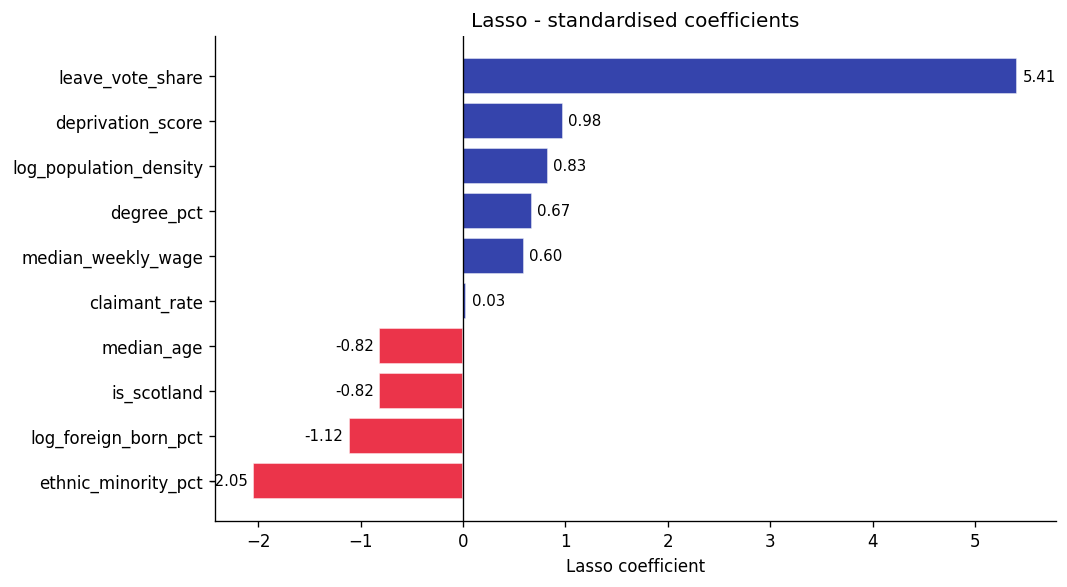

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [REFORM_COLOR if c > 0 else ACCENT_COLOR if c < 0 else 'lightgrey'
          for c in lasso_coef['coef']]
bars = ax.barh(lasso_coef['feature'], lasso_coef['coef'],
               color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel("Lasso coefficient")
ax.set_title("Lasso - standardised coefficients")
for bar, val in zip(bars, lasso_coef['coef']):
    if val != 0:
        ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('../../outputs/models_lasso_coef.png', bbox_inches='tight')
plt.show()

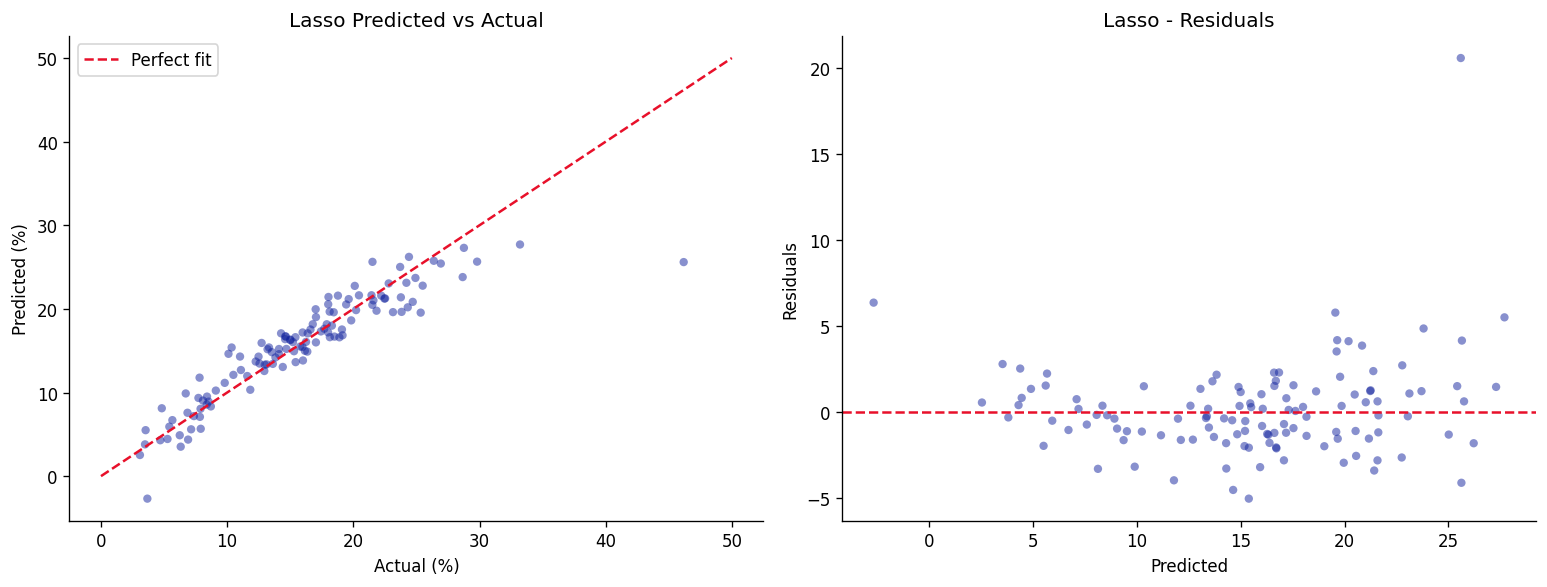

In [37]:
# predicted vs actual + residuals for champion
residuals_lasso = y_test - y_pred_lasso

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_lasso, alpha=0.5, s=25, color=REFORM_COLOR, edgecolors='none')
ax.plot([0, 50], [0, 50], color=ACCENT_COLOR, lw=1.5, linestyle='--', label='Perfect fit')
ax.set_xlabel("Actual (%)")
ax.set_ylabel("Predicted (%)")
ax.set_title("Lasso Predicted vs Actual")
ax.legend()

ax = axes[1]
ax.scatter(y_pred_lasso, residuals_lasso, alpha=0.5, s=25, color=REFORM_COLOR, edgecolors='none')
ax.axhline(0, color=ACCENT_COLOR, lw=1.5, linestyle='--')
ax.set_xlabel("Predicted")
ax.set_ylabel("Residuals")
ax.set_title("Lasso - Residuals")

plt.tight_layout()
plt.savefig('../../outputs/models_lasso_residuals.png', bbox_inches='tight')
plt.show()

In [38]:
errors_df = pd.DataFrame({
    'constituency': df.loc[y_test.index, 'constituency'].values,
    'actual': y_test.values.round(2),
    'predicted': y_pred_lasso.round(2),
    'residual': residuals_lasso.values.round(2),
    'abs_error': np.abs(residuals_lasso.values).round(2),
})

print("Largest errors:")
display(errors_df.sort_values('abs_error', ascending=False).head(10))

Largest errors:


,constituency,actual,predicted,residual,abs_error
7,Clacton,46.18,25.60,20.59,20.59
76,Edinburgh North and Leith,3.67,-2.69,6.37,6.37
37,Neath and Swansea East,25.34,19.55,5.79,5.79
45,Barnsley South,33.21,27.70,5.51,5.51
108,Keighley and Ilkley,10.35,15.38,-5.03,5.03
6,Amber Valley,28.67,23.80,4.86,4.86
26,Liverpool Riverside,10.10,14.63,-4.52,4.52
0,Warrington North,23.83,19.64,4.18,4.18
51,Easington,29.81,25.65,4.16,4.16
62,Brentwood and Ongar,24.31,20.19,4.12,4.12


## Challenger 1: Linear Regression (VIF-reduced)

Manual approach to multicollinearity: drop features iteratively until VIF < 10.
Leave_vote_share drops out naturally, making this a demographic-only model.
Included to contrast with Lasso's automatic regularisation approach.

In [39]:
lr_vif = LinearRegression().fit(X_train_vif, y_train)
y_pred_lr = lr_vif.predict(X_test_vif)
cv_lr = cross_val_score(lr_vif, X_train_vif, y_train, cv=5, scoring='r2').mean()

metrics("LR - VIF-reduced", y_test, y_pred_lr, cv_lr)
print(f"Features: {FEATURES_VIF}")

LR - VIF-reduced                     R²=0.7203  CV=0.7296  MAE=2.6347  RMSE=3.7248
Features: ['degree_pct', 'ethnic_minority_pct', 'deprivation_score', 'is_scotland']


## Challenger 2: Random Forest

In [40]:
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [200, 300], 'max_depth': [5, 10, None], 'min_samples_leaf': [1, 3, 5]},
    cv=5, scoring='r2', n_jobs=-1
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
cv_rf = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2').mean()

print(f"Best params: {grid_rf.best_params_}")
metrics("Random Forest", y_test, y_pred_rf, cv_rf)

Best params: {'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 300}
Random Forest                        R²=0.8816  CV=0.8520  MAE=1.6909  RMSE=2.4237


## Challenger 3: Gradient Boosting

In [41]:
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {'n_estimators': [200, 300], 'max_depth': [3, 5],
     'learning_rate': [0.05, 0.1], 'min_samples_leaf': [3, 5]},
    cv=5, scoring='r2', n_jobs=-1
)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)
cv_gb = cross_val_score(best_gb, X_train, y_train, cv=5, scoring='r2').mean()

print(f"Best params: {grid_gb.best_params_}")
metrics("Gradient Boosting", y_test, y_pred_gb, cv_gb)

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}
Gradient Boosting                    R²=0.8607  CV=0.8488  MAE=1.8273  RMSE=2.6281


In [42]:
preds = [y_pred_lasso, y_pred_lr, y_pred_rf, y_pred_gb]
names = ['Lasso', 'LR (VIF-reduced)', 'Random Forest', 'Gradient Boosting']
cvs   = [cv_lasso, cv_lr, cv_rf, cv_gb]

results = pd.DataFrame({
    'Model': names,
    'R² Test': [r2_score(y_test, p) for p in preds],
    'R² CV-5': cvs,
    'MAE': [mean_absolute_error(y_test, p) for p in preds],
    'RMSE':[np.sqrt(mean_squared_error(y_test, p)) for p in preds],
}).round(4)
results['Gap'] = (results['R² Test'] - results['R² CV-5']).round(4)

display(results)

,Model,R² Test,R² CV-5,MAE,RMSE,Gap
0,Lasso,0.8395,0.8429,1.8149,2.8211,-0.0034
1,LR (VIF-reduced),0.7203,0.7296,2.6347,3.7248,-0.0093
2,Random Forest,0.8816,0.8520,1.6909,2.4237,0.0296
3,Gradient Boosting,0.8607,0.8488,1.8273,2.6281,0.0119


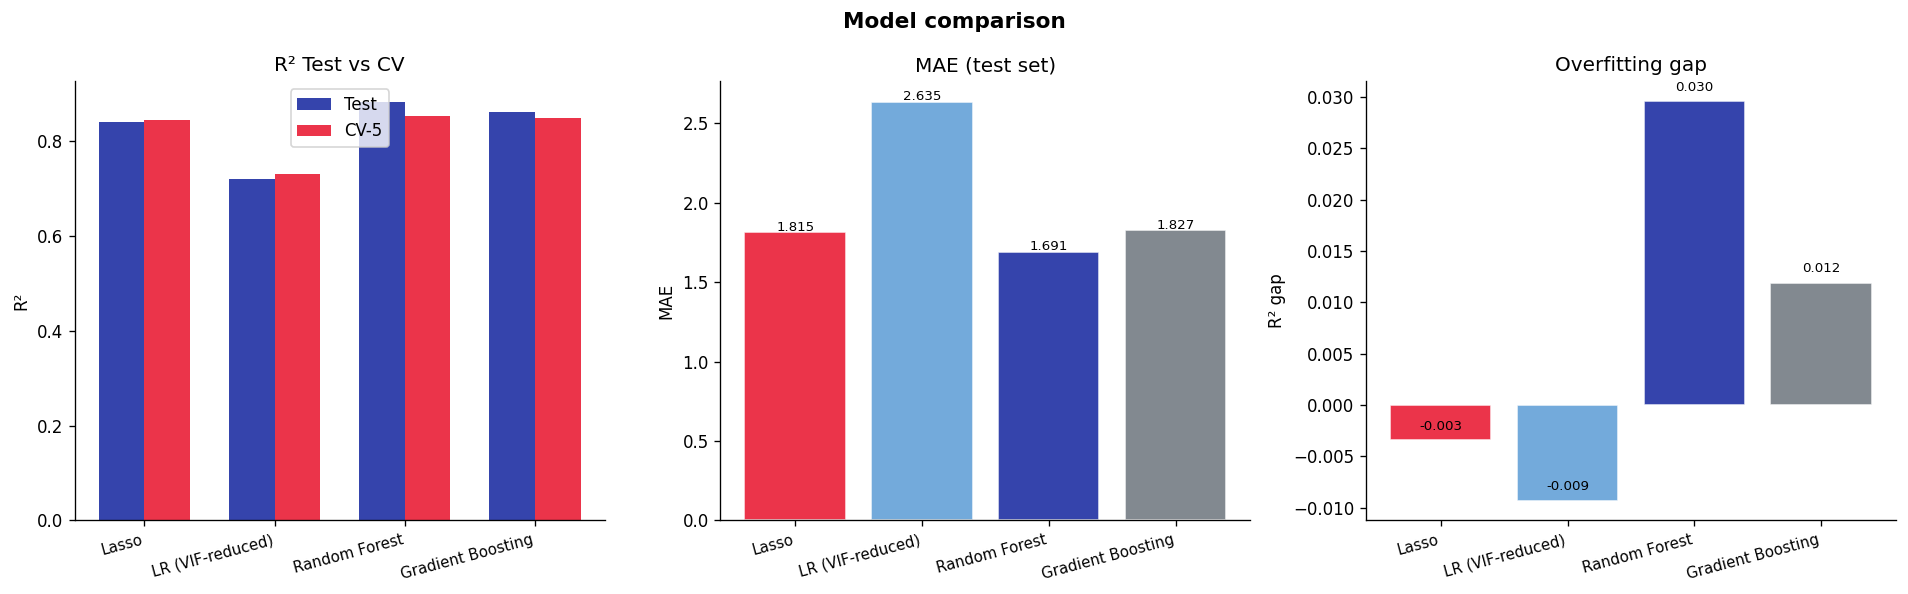

In [43]:
colors_bar = [ACCENT_COLOR, '#5B9BD5', REFORM_COLOR, '#6c757d']
x = np.arange(len(results))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.bar(x - w/2, results['R² Test'], w, label='Test', color=REFORM_COLOR, alpha=0.85)
ax.bar(x + w/2, results['R² CV-5'], w, label='CV-5', color=ACCENT_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel("R²")
ax.set_title("R² Test vs CV")
ax.legend()

ax = axes[1]
bars = ax.bar(names, results['MAE'], color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_ylabel("MAE")
ax.set_title("MAE (test set)")
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars, results['MAE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=8)

ax = axes[2]
bars = ax.bar(names, results['Gap'], color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_ylabel("R² gap")
ax.set_title("Overfitting gap")
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars, results['Gap']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=8)

plt.suptitle("Model comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/models_01_comparison.png', bbox_inches='tight')
plt.show()

In [45]:
# no-Brexit analysis, remove only leave_vote_share, keep everything else to see how much
# of Reform's geography is Brexit vote vs demographics

FEATURES_NO_BREXIT = [f for f in FEATURES if f != 'leave_vote_share']

X_nb = df[FEATURES_NO_BREXIT]
X_train_nb, X_test_nb, _, _ = train_test_split(X_nb, y, test_size=0.2, random_state=42)

scaler_nb = StandardScaler()
X_train_nb_sc = scaler_nb.fit_transform(X_train_nb)
X_test_nb_sc  = scaler_nb.transform(X_test_nb)

grid_nb = GridSearchCV(
    Lasso(max_iter=10000),
    {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]},
    cv=5, scoring='r2'
)
grid_nb.fit(X_train_nb_sc, y_train)
best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test_nb_sc)
cv_nb = cross_val_score(best_nb, X_train_nb_sc, y_train, cv=5, scoring='r2').mean()

metrics("Lasso - full model",          y_test, y_pred_lasso, cv_lasso)
metrics("Lasso - without Brexit vote", y_test, y_pred_nb,    cv_nb)
print(f"\nCV R² drop: {cv_lasso - cv_nb:.4f}")

Lasso - full model                   R²=0.8395  CV=0.8429  MAE=1.8149  RMSE=2.8211
Lasso - without Brexit vote          R²=0.7310  CV=0.7514  MAE=2.5733  RMSE=3.6526

CV R² drop: 0.0916


## Key findings

Lasso achieves CV R²=0.843 with a near-zero overfitting gap (-0.003), confirming strong
out-of-sample generalisation. Ensemble methods gain a few points on the test set but show
larger overfitting gaps - Random Forest gap of 0.029 vs Lasso's -0.003, expected with
607 observations and 10 features.

The VIF-reduced LR (CV R²=0.730) shows the cost of manual multicollinearity handling:
dropping 6 features, including leave_vote_share, reduces performance by 11 points.
Running Lasso without leave_vote_share gives CV R²=0.751, meaning
demographic variables alone explain around 75% of Reform's geographic variation.
Brexit factor adds 9.2 percentage points on top, which is significant, but the underlying
 structure was already largely predictive without it.

Claimant rate was zeroed out or near-zeroed by Lasso, validating the EDA finding
that unemployment does not predict Reform support independently of other variables.